# 🛒 EPOCH 5th Pilot Task Week2 (박정민)
> **주제: BMI 지수와 실제 비만 등급의 괴리 분석**
>> 부제: BMI 지표의 한계 극복을 위한 생활 습관 기반 비만 위험도 재정의


## Week1 정리

### 컬럼 정보
- 수치형
> - Age : 나이
> - Height: 키
> - Weight: 몸무게
> - FCVC : 채소 섭취 빈도
> - NCP : 하루 섭취 끼니수
> - CH2O: 하루 섭취 물 양
> - FAF: 신체 활동 빈도
> - TUE : 전자기기 사용 빈도(휴대폰, 비디오게임, TV, 컴퓨터 등)

- 범주형
> - Gender: 성별
> - family_history_with_overweight: 과체중 가족력
> - FAVC : 고칼로리 음식 섭취 빈도
> - CAEC : 식사 사이 군것질 빈도
> - SMOKE : 흡연 여부
> - SCC: 섭취 칼로리 모니터링 여부
> - CALC : 알콜 섭취 빈도
> - MTRANS : 주로 사용하는 교통수단
> - NObeyesdad : 비만 수준

### Week1 추후 분석 방향
- Feature Engineering: BMI 지수나 실제 비만 수준에 연관이 있을만한 피쳐들을 합치는 작업 진행, 또한 범주형 변수 9개를 One-Hot Encoding을 통한 라벨링 진행
- 데이터셋 목적 구체화: 해당 데이터셋으로 진행할 수 있는 다양한 분석 주제 중 하나의 방향을 구체화하여 모델링 및 Baseline 작성
- 데이터 검증: 77%의 데이터가 SMOTE로 만들어져 있기에, 데이터셋의 성능을 모델링을 통해 검증 진행
- 모델링: 트리 앙상블 기법이나, XAI를 통해 해석력을 보충하여 "전통적인 BMI지표가 포착하지 못하는 생활 습관 기반의 비만 위험도를 규명하고, 검증"하도록 진행

## Task1. 데이터 전처리

### 0. 라이브러리 및 데이터 불러오기

In [67]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
import warnings
warnings.filterwarnings('ignore')

In [100]:
pd.set_option('display.max_columns', None)

In [69]:
df = pd.read_csv('ObesityDataSet_raw.csv')
df_raw = df.copy()

### 1. 변수명 수정하기

In [70]:
# 변수명 매핑 딕셔너리
rename_dict = {
    'Gender': 'gender',
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'family_history_with_overweight': 'family_history',
    'FAVC': 'high_cal_food',
    'FCVC': 'vegetable',
    'NCP': 'meal_count',
    'CAEC': 'snack',
    'SMOKE': 'smoke',
    'CH2O': 'water_intake',
    'SCC': 'cal_monitoring',
    'FAF': 'physical_activity',
    'TUE': 'tech_time',
    'CALC': 'alcohol_intake',
    'MTRANS': 'transport',
    'NObeyesdad': 'obesity_level'
}

df.rename(columns=rename_dict, inplace=True)
print(df.columns)

Index(['age', 'gender', 'height', 'weight', 'alcohol_intake', 'high_cal_food',
       'vegetable', 'meal_count', 'cal_monitoring', 'smoke', 'water_intake',
       'family_history', 'physical_activity', 'tech_time', 'snack',
       'transport', 'obesity_level'],
      dtype='object')


In [71]:
df.head()

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 2. 결측치 확인

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2111 non-null   float64
 1   gender             2111 non-null   object 
 2   height             2111 non-null   float64
 3   weight             2111 non-null   float64
 4   alcohol_intake     2111 non-null   object 
 5   high_cal_food      2111 non-null   object 
 6   vegetable          2111 non-null   float64
 7   meal_count         2111 non-null   float64
 8   cal_monitoring     2111 non-null   object 
 9   smoke              2111 non-null   object 
 10  water_intake       2111 non-null   float64
 11  family_history     2111 non-null   object 
 12  physical_activity  2111 non-null   float64
 13  tech_time          2111 non-null   float64
 14  snack              2111 non-null   object 
 15  transport          2111 non-null   object 
 16  obesity_level      2111 

In [51]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
alcohol_intake,0
high_cal_food,0
vegetable,0
meal_count,0
cal_monitoring,0
smoke,0


### 3. 중복데이터 제거

In [72]:
df_recolumn = df.copy()
df_recolumn.head()

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [73]:
df.duplicated().sum()

np.int64(24)

In [74]:
df.drop_duplicates(inplace=True)

In [75]:
print(df_raw.shape)
print(df.shape)  # 중복데이터 24개 제거 완료

(2111, 17)
(2087, 17)


In [76]:
# 중복데이터까지 제거한 df 저장
df_dup = df.copy()

### 4. 이상치 확인

In [77]:
num_cols = ['age', 'height', 'weight', 'vegetable', 'meal_count', 'water_intake', 'physical_activity', 'tech_time']
cat_cols = ['gender', 'family_history', 'high_cal_food', 'snack',
            'smoke', 'cal_monitoring', 'alcohol_intake', 'transport', 'obesity_level']

#### 4-1. 수치형 변수 이상치 확인

In [78]:
df.describe() # 수치형만

,age,height,weight,vegetable,meal_count,water_intake,physical_activity,tech_time
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


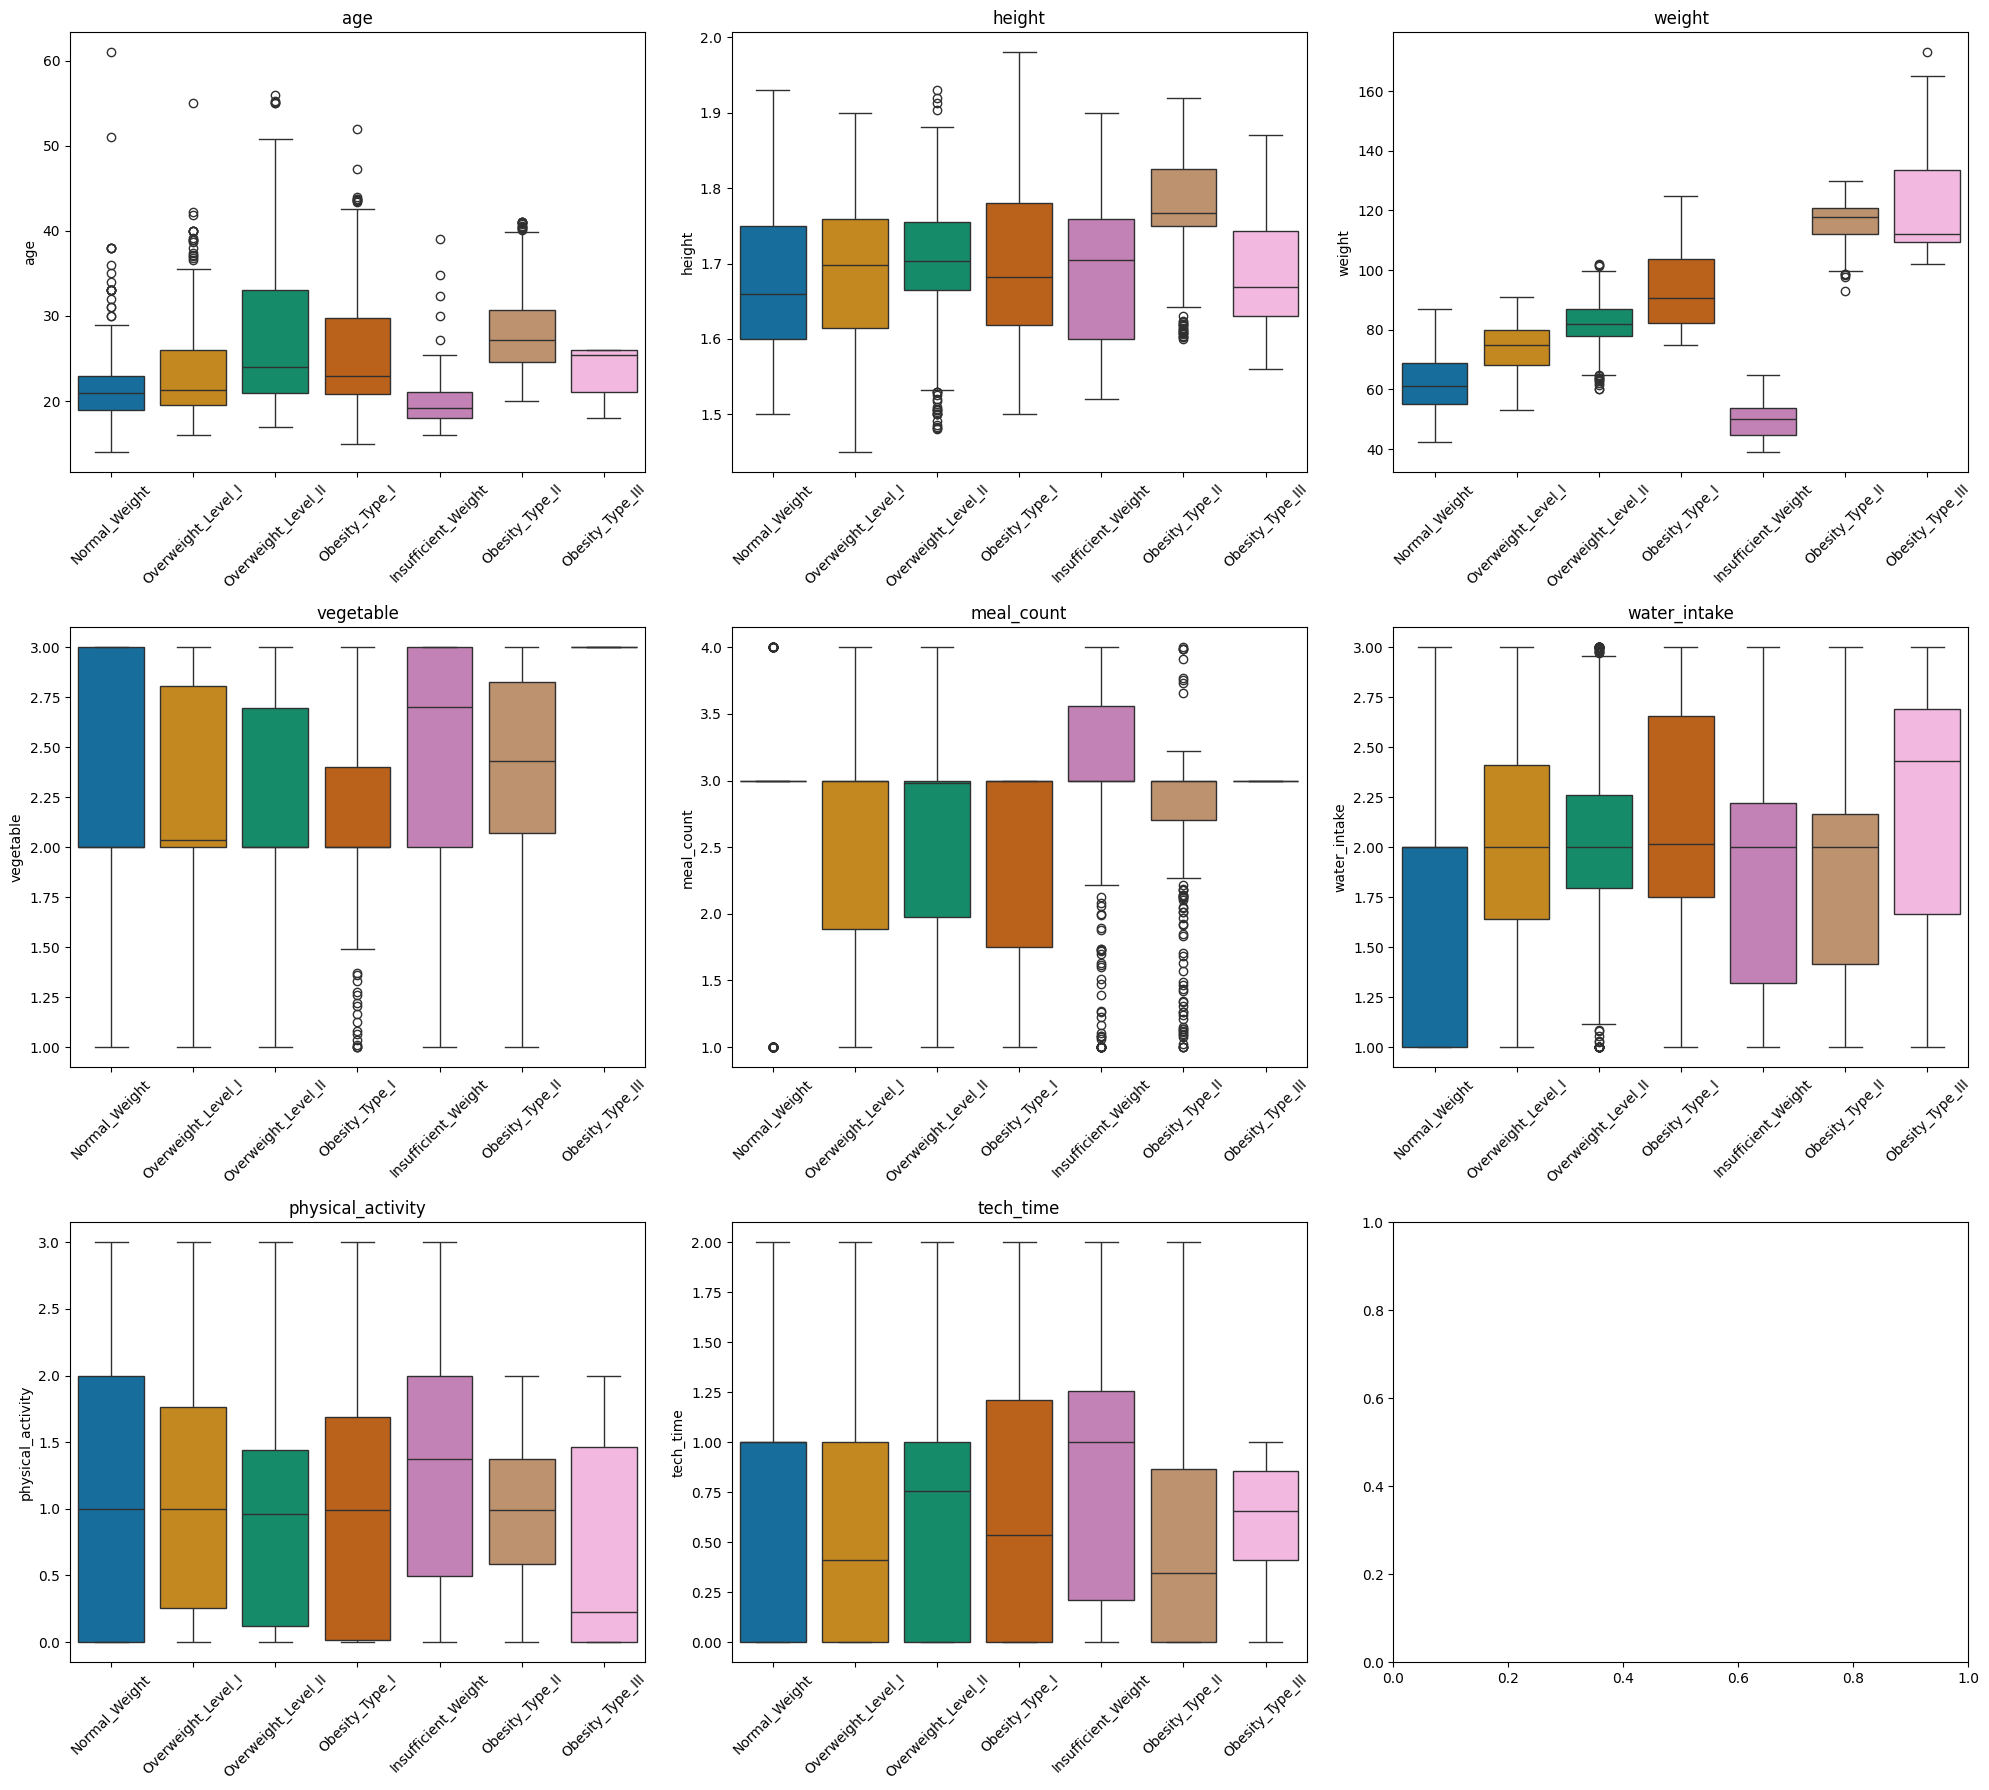

In [79]:
# 비만 수준에 따른 수치형 변수 시각화
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='obesity_level', y=col, ax=axes[i],
                hue='obesity_level', palette='colorblind', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

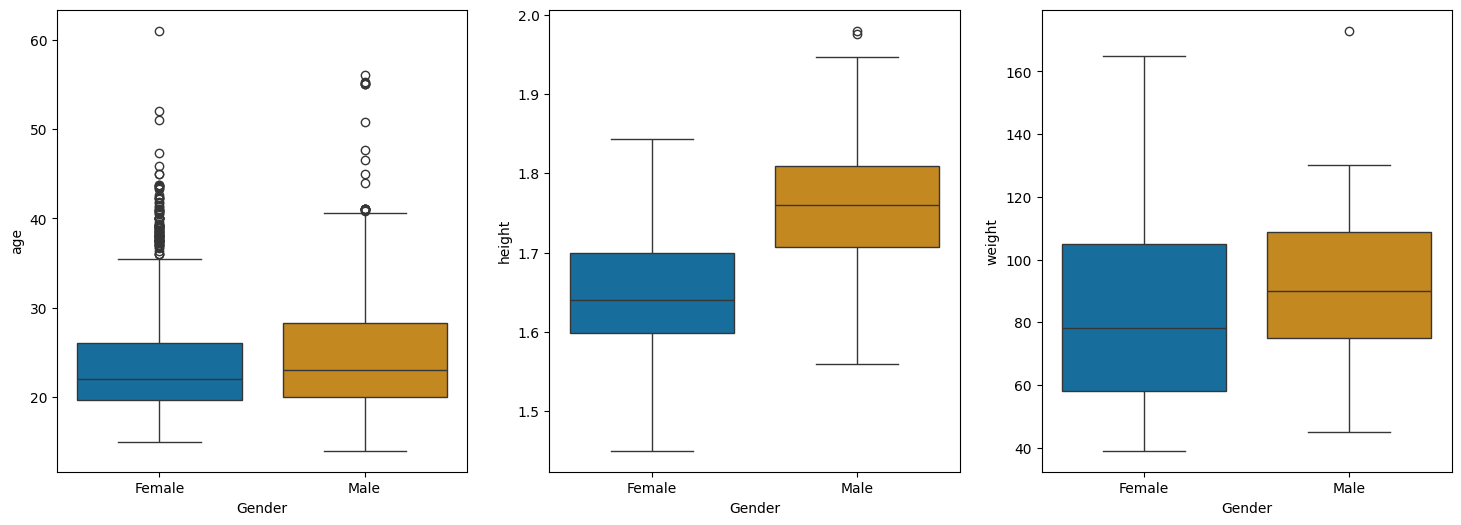

In [80]:
# 성별에 따른 나이, 키, 몸무게 시각화
features = ['age', 'height', 'weight']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features):
    sns.boxplot(x='gender', y=col, data=df, ax=axes[i], palette='colorblind')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel(col)
plt.show()

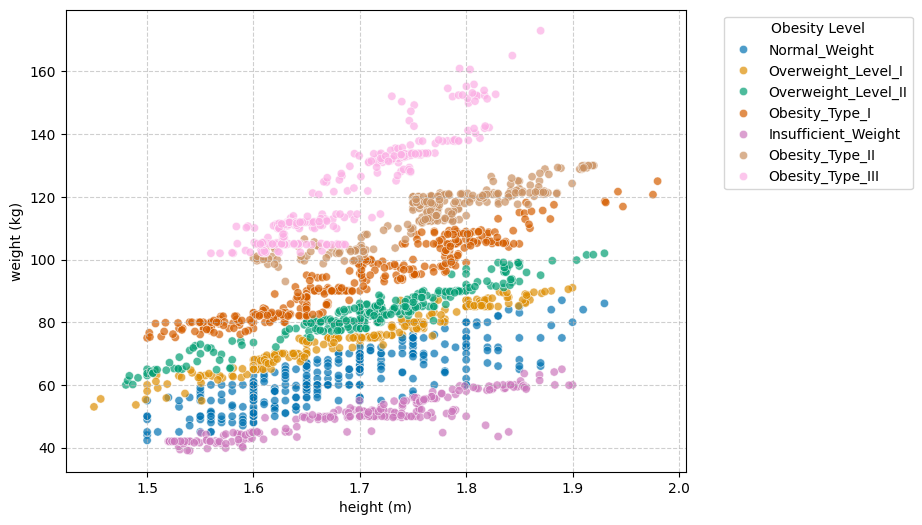

In [81]:
# 키와 몸무게의 산점도 그림
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='height', y='weight', hue='obesity_level',
                palette='colorblind', alpha=0.7)

plt.xlabel('height (m)')
plt.ylabel('weight (kg)')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- 해당 수치 데이터에 대한 이상치는 매우 정상으로 보인다.

#### 4-2. 범주형 데이터 확인

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2087 non-null   float64
 1   gender             2087 non-null   object 
 2   height             2087 non-null   float64
 3   weight             2087 non-null   float64
 4   alcohol_intake     2087 non-null   object 
 5   high_cal_food      2087 non-null   object 
 6   vegetable          2087 non-null   float64
 7   meal_count         2087 non-null   float64
 8   cal_monitoring     2087 non-null   object 
 9   smoke              2087 non-null   object 
 10  water_intake       2087 non-null   float64
 11  family_history     2087 non-null   object 
 12  physical_activity  2087 non-null   float64
 13  tech_time          2087 non-null   float64
 14  snack              2087 non-null   object 
 15  transport          2087 non-null   object 
 16  obesity_level      2087 non-n

- 범주형 변수는 dtype이 object로 되어있다.

In [83]:
df.describe(include='object')  # 범주형 데이터만

,gender,alcohol_intake,high_cal_food,cal_monitoring,smoke,family_history,snack,transport,obesity_level
count,2087,2087,2087,2087,2087,2087,2087,2087,2087
unique,2,4,2,2,2,2,4,5,7
top,Male,Sometimes,yes,no,no,yes,Sometimes,Public_Transportation,Obesity_Type_I
freq,1052,1380,1844,1991,2043,1722,1761,1558,351


- 각 변수의 unique값이 2 ~ 7개로 굉장히 합당하게 되어 있는 모습.

In [84]:
for col in cat_cols:
    print("===[", col, "]===")
    count = df[col].value_counts()
    ratio = df[col].value_counts(normalize=True) * 100

    report = pd.DataFrame({'Count': count, 'Percentage (%)': ratio.round(2)})
    print(report)
    print("\n")

===[ gender ]===
        Count  Percentage (%)
gender                       
Male     1052           50.41
Female   1035           49.59


===[ family_history ]===
                Count  Percentage (%)
family_history                       
yes              1722           82.51
no                365           17.49


===[ high_cal_food ]===
               Count  Percentage (%)
high_cal_food                       
yes             1844           88.36
no               243           11.64


===[ snack ]===
            Count  Percentage (%)
snack                            
Sometimes    1761           84.38
Frequently    236           11.31
Always         53            2.54
no             37            1.77


===[ smoke ]===
       Count  Percentage (%)
smoke                       
no      2043           97.89
yes       44            2.11


===[ cal_monitoring ]===
                Count  Percentage (%)
cal_monitoring                       
no               1991            95.4
yes          

- 이상치 문제가 없는 변수
> gender, family_history, high\_cal\_food, obesity_level

- 희소한 카테고리가 있는 변수
> smoke(2.11%), cal_monitoring(4.6%), transport(2.64, 0.53, 0.34)

- 매우 희소한 카테고리가 있는 변수
> alcohol_intake(Always -> 1개, 0.05%)

In [85]:
# 알코올 섭취에 always를 선택한 행 확인
df[df['alcohol_intake'] == 'Always']

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level
26,21.0,Male,1.7,65.0,Always,yes,2.0,1.0,no,no,2.0,yes,1.0,2.0,Frequently,Walking,Normal_Weight


- 해당 사람은 하루 1끼, 칼로리 모니터링도 안하고, 가족력이 있으며, 운동도 많이 안하고, 간식도 많이 섭취하고, 알코올을 매일 마시지만, 주로 걷기를 하며 정상 비만 수준이다!!

=> 따라서 모든 데이터가 이상치가 있다고 보기 어려움, 이상치 제거를 하지 않은채로 모델링을 진행해보면 좋을 것 같다.

## Task2. 피쳐 엔지니어링

### 1. BMI 기반 파생 변수 생성

In [98]:
# BMI 수치 계산 [공식: BMI = 몸무게(kg) / 키(m)^2]
df['bmi_score'] = df['weight'] / (df['height']**2)

# WHO 표준 기준에 따른 BMI 등급 부여 (비교용)
def get_bmi_label(bmi):
    if bmi < 18.5: return 'Insufficient_Weight'
    elif bmi < 25: return 'Normal_Weight'
    elif bmi < 30: return 'Overweight'
    else: return 'Obesity' # 30 이상은 표준상 모두 비만

df['bmi_label'] = df['bmi_score'].apply(get_bmi_label)

# 데이터 상 비만 수준(obesity_level) 단순화 (비교를 위해 Obesity Type I, II, III를 하나로 통합)
df['actual_label_simplified'] = df['obesity_level'].apply(
    lambda x: 'Obesity' if 'Obesity' in x else ('Overweight' if 'Overweight' in x else x)
)

# 괴리 여부 확인 (Mismatch Flag)
# BMI 등급과 실제 진단 등급이 다르면 1, 같으면 0
df['is_mismatch'] = (df['bmi_label'] != df['actual_label_simplified']).astype(int)

print(f"전체 데이터 중 괴리가 발생하는 샘플 수: {df['is_mismatch'].sum()}개")
print(f"괴리율: {df['is_mismatch'].mean():.2%}")

전체 데이터 중 괴리가 발생하는 샘플 수: 25개
괴리율: 1.20%


In [101]:
df.head(10)

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level,bmi_score,bmi_label,actual_label_simplified,is_mismatch
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,24.386526,Normal_Weight,Normal_Weight,0
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Normal_Weight,Normal_Weight,0
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,23.765432,Normal_Weight,Normal_Weight,0
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,26.851852,Overweight,Overweight,0
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Overweight,Overweight,0
5,29.0,Male,1.62,53.0,Sometimes,yes,2.0,3.0,no,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight,20.195092,Normal_Weight,Normal_Weight,0
6,23.0,Female,1.50,55.0,Sometimes,yes,3.0,3.0,no,no,2.0,yes,1.0,0.0,Sometimes,Motorbike,Normal_Weight,24.444444,Normal_Weight,Normal_Weight,0
7,22.0,Male,1.64,53.0,Sometimes,no,2.0,3.0,no,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,19.705532,Normal_Weight,Normal_Weight,0
8,24.0,Male,1.78,64.0,Frequently,yes,3.0,3.0,no,no,2.0,yes,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight,20.199470,Normal_Weight,Normal_Weight,0
9,22.0,Male,1.72,68.0,no,yes,2.0,3.0,no,no,2.0,yes,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight,22.985398,Normal_Weight,Normal_Weight,0


In [112]:
# 괴리가 발생하는 25명의 데이터만 따로 추출
mismatch_df = df[df['is_mismatch'] == 1]

# 이들의 평균적인 특성 확인
print("--- 괴리 그룹의 평균 특성 ---")
print(mismatch_df[['age', 'height', 'weight', 'bmi_score', 'physical_activity']].mean())

# 이들의 비만 등급 분포 확인
print("\n--- 괴리 그룹의 실제 등급 분포 ---")
print(mismatch_df['obesity_level'].value_counts())

--- 괴리 그룹의 평균 특성 ---
age                  23.076510
height                1.622967
weight               63.806996
bmi_score            24.190460
physical_activity     0.838117
dtype: float64

--- 괴리 그룹의 실제 등급 분포 ---
obesity_level
Overweight_Level_I     12
Overweight_Level_II     4
Insufficient_Weight     4
Normal_Weight           3
Obesity_Type_I          2
Name: count, dtype: int64


### 2. 나이가 과연 비만에 큰 영향을 줄까?

In [ ]:
# 비만 수준에 따른 수치형 변수 시각화
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='obesity_level', y=col, ax=axes[i],
                hue='obesity_level', palette='colorblind', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

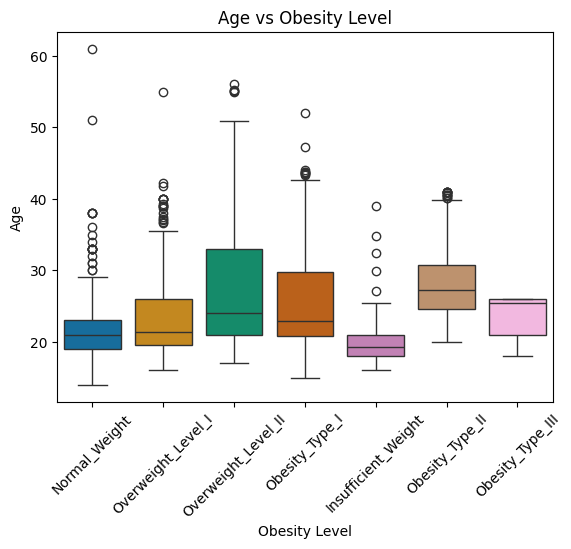

In [107]:
sns.boxplot(data=df, x='obesity_level', y='age', palette='colorblind')
plt.title('Age vs Obesity Level')
plt.xlabel('Obesity Level')
plt.ylabel('Age')
plt.tick_params(axis='x', rotation=45)
plt.show()

In [110]:
# 등급별 평균 나이 확인
print(df.groupby('obesity_level')['age'].mean().sort_values())

obesity_level
Insufficient_Weight    19.771687
Normal_Weight          21.758865
Obesity_Type_III       23.495554
Overweight_Level_I     23.540309
Obesity_Type_I         25.884941
Overweight_Level_II    26.996981
Obesity_Type_II        28.233785
Name: age, dtype: float64


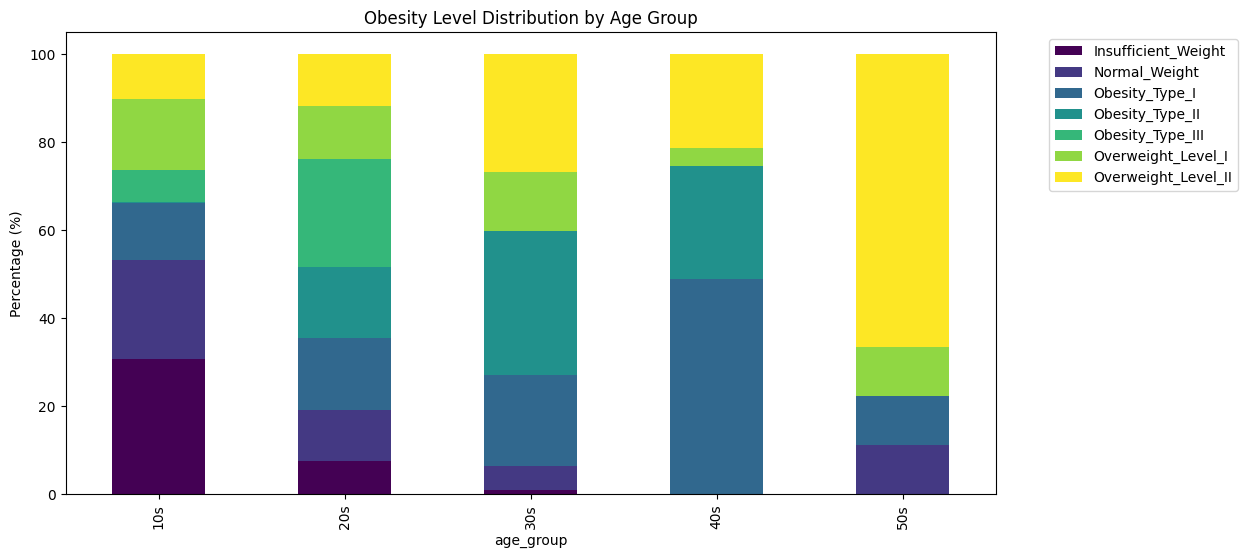

In [108]:
# 나이대 변수 생성
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60], labels=['10s', '20s', '30s', '40s', '50s'])

# 나이대별 비만 등급 비중 계산
age_obesity_pct = pd.crosstab(df['age_group'], df['obesity_level'], normalize='index') * 100

# 시각화
age_obesity_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Obesity Level Distribution by Age Group')
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

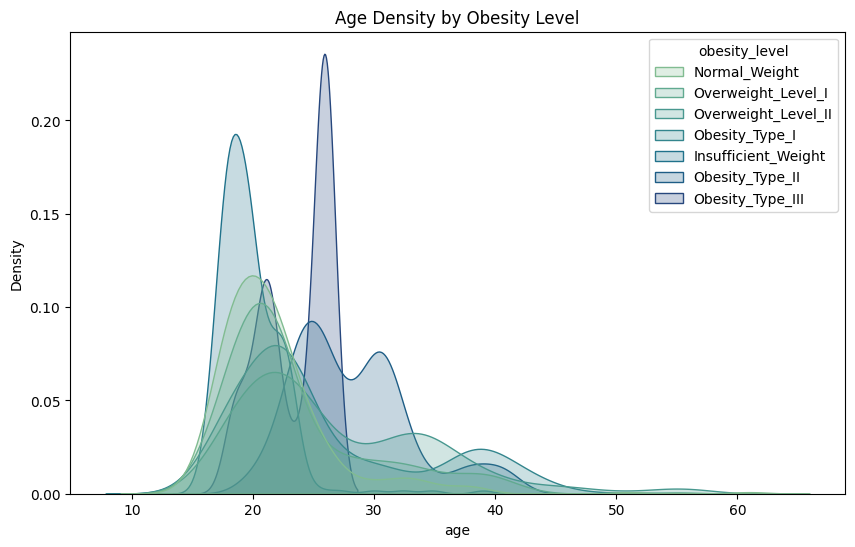

In [109]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='obesity_level', fill=True, common_norm=False, palette='crest')
plt.title('Age Density by Obesity Level')
plt.show()

### 3. 상관관계 확인

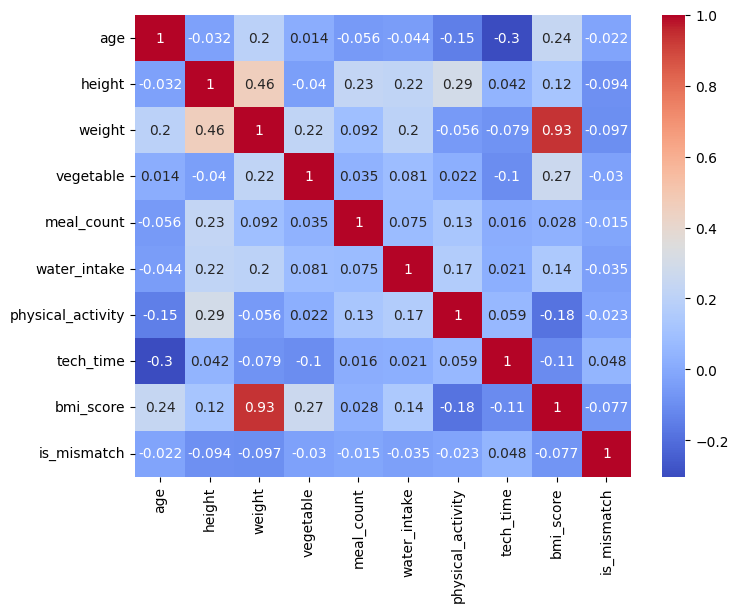

In [113]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.yticks(rotation=0)
plt.show()

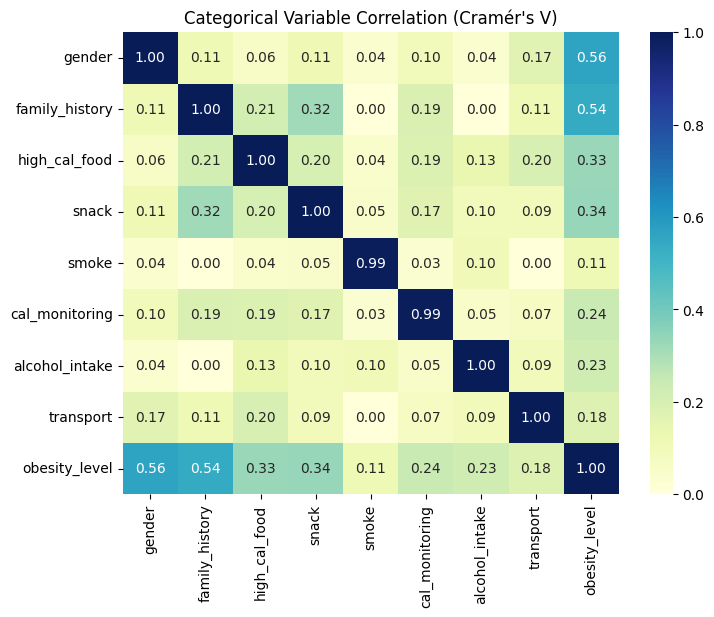

In [114]:
# 범주형 크래머 V 계수를 활용한 상관관계 확인 (카이제곱)
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

rows = []
for x in cat_cols:
    col = []
    for y in cat_cols:
        col.append(cramers_v(df[x], df[y]))
    rows.append(col)

v_matrix = pd.DataFrame(rows, columns=cat_cols, index=cat_cols)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Categorical Variable Correlation (Cramér's V)")
plt.show()

- 해당 상관계수를 보며 파생변수 생성

In [119]:
from sklearn.preprocessing import MinMaxScaler

# 숫자 매핑 (인코딩)
binary_map = {'yes': 1, 'no': 0}
snack_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
alc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

df['high_cal_num'] = df['high_cal_food'].map(binary_map)
df['snack_num'] = df['snack'].map(snack_map)
df['alc_num'] = df['alcohol_intake'].map(alc_map)

# 스케일링할 컬럼 선택
features_to_scale = ['high_cal_num', 'snack_num', 'alc_num',
                     'vegetable', 'physical_activity', 'water_intake']

# MinMaxScaler 적용 (새 파생변수를 위해 스케일을 맞춰주기)
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[features_to_scale])

# 결과를 데이터프레임으로 다시 만들기 (가독성을 위해)
scaled_df = pd.DataFrame(scaled_values, columns=[f's_{col}' for col in features_to_scale])

# 종합 습관 위험 점수 계산
# 안 좋은 습관(s_high_cal, s_snack, s_alc) - 좋은 습관(s_veg, s_exercise, s_water)
df['habit_risk_score'] = (scaled_df['s_high_cal_num'] + scaled_df['s_snack_num'] + scaled_df['s_alc_num']) - \
                         (scaled_df['s_vegetable'] + scaled_df['s_physical_activity'] + scaled_df['s_water_intake'])

# 나이 가중치 적용 (2번에서의 추가적인 파생변수)
df['age_buffer_index'] = df['habit_risk_score'] / (df['age'] + 0.001)
df[['habit_risk_score', 'age_buffer_index']].head()

,habit_risk_score,age_buffer_index
0,-0.666667,-0.031745
1,-2.333333,-0.111106
2,-0.666667,-0.028984
3,-1.166667,-0.043208
4,-0.333333,-0.015151


In [120]:
df.head()

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level,bmi_score,bmi_label,actual_label_simplified,is_mismatch,age_group,snack_num,alc_num,high_cal_num,habit_risk_score,age_buffer_index
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,24.386526,Normal_Weight,Normal_Weight,0,20s,1,0,0,-0.666667,-0.031745
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Normal_Weight,Normal_Weight,0,20s,1,1,0,-2.333333,-0.111106
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,23.765432,Normal_Weight,Normal_Weight,0,20s,1,2,0,-0.666667,-0.028984
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,26.851852,Overweight,Overweight,0,20s,1,2,0,-1.166667,-0.043208
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Overweight,Overweight,0,20s,1,1,0,-0.333333,-0.015151


             habit_risk_score  age_buffer_index  physical_activity        age
is_mismatch                                                                  
0                   -0.039970         -0.001468           1.014930  24.368567
1                   -0.011715          0.000993           0.838117  23.076510


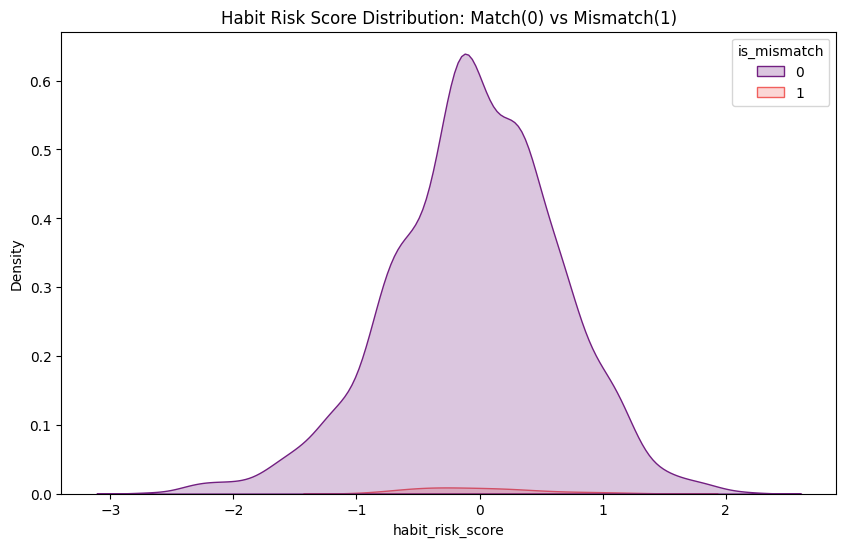

In [121]:
comparison = df.groupby('is_mismatch')[['habit_risk_score', 'age_buffer_index', 'physical_activity', 'age']].mean()
print(comparison)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='habit_risk_score', hue='is_mismatch', fill=True, palette='magma')
plt.title('Habit Risk Score Distribution: Match(0) vs Mismatch(1)')
plt.show()

- 나이에 따른 괴리 그룹 확인
  - 괴리그룹(1)은 나이 파생변수가 양수이다. 이는 BMI에 따른 비만 수준은 다르지만, 나이에 영향을 받는다는 지표로 활용이 가능하다.
- 운동 관련 파생변수
  - 확실히 괴리그룹(1)이 운동이 살짝 부족한 모습
  - 이는 BMI는 정상이지만, 체지방률은 높은 마른 비만 형태가 가능하다는 증거로 사용가능하다.

## 추가. 범주형 변수 Encoding

In [123]:
# 인코딩 이전까지 df_raw2 저장
df_raw2 = df.copy()
df_raw2.head()

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level,bmi_score,bmi_label,actual_label_simplified,is_mismatch,age_group,snack_num,alc_num,high_cal_num,habit_risk_score,age_buffer_index
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,24.386526,Normal_Weight,Normal_Weight,0,20s,1,0,0,-0.666667,-0.031745
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Normal_Weight,Normal_Weight,0,20s,1,1,0,-2.333333,-0.111106
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,23.765432,Normal_Weight,Normal_Weight,0,20s,1,2,0,-0.666667,-0.028984
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,26.851852,Overweight,Overweight,0,20s,1,2,0,-1.166667,-0.043208
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Overweight,Overweight,0,20s,1,1,0,-0.333333,-0.015151


In [124]:
from sklearn.preprocessing import LabelEncoder

df_final = df.copy()

# 이진 및 순서형 수동 매핑
binary_map = {'yes': 1, 'no': 0}
gender_map = {'Male': 1, 'Female': 0}

df_final['gender'] = df_final['gender'].map(gender_map)
for col in ['high_cal_food', 'smoke', 'cal_monitoring', 'family_history']:
    df_final[col] = df_final[col].map(binary_map)

# 명목형 변수 원-핫 인코딩 (transport)
df_final = pd.get_dummies(df_final, columns=['transport'], drop_first=True)

# 타겟 변수 인코딩 (obesity_level)
obesity_map = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1,
    'Overweight_Level_I': 2, 'Overweight_Level_II': 3,
    'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
df_final['obesity_target'] = df_final['obesity_level'].map(obesity_map)

drop_cols = ['snack', 'alcohol_intake', 'obesity_level', 'bmi_label',
             'actual_label_simplified', 'age_group']
df_final = df_final.drop(columns=drop_cols)

print("모델 학습용 최종 인코딩 완료!")
df_final.head()

모델 학습용 최종 인코딩 완료!


,age,gender,height,weight,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,bmi_score,is_mismatch,snack_num,alc_num,high_cal_num,habit_risk_score,age_buffer_index,transport_Bike,transport_Motorbike,transport_Public_Transportation,transport_Walking,obesity_target
0,21.0,0,1.62,64.0,0,2.0,3.0,0,0,2.0,1,0.0,1.0,24.386526,0,1,0,0,-0.666667,-0.031745,False,False,True,False,1
1,21.0,0,1.52,56.0,0,3.0,3.0,1,1,3.0,1,3.0,0.0,24.238227,0,1,1,0,-2.333333,-0.111106,False,False,True,False,1
2,23.0,1,1.80,77.0,0,2.0,3.0,0,0,2.0,1,2.0,1.0,23.765432,0,1,2,0,-0.666667,-0.028984,False,False,True,False,1
3,27.0,1,1.80,87.0,0,3.0,3.0,0,0,2.0,0,2.0,0.0,26.851852,0,1,2,0,-1.166667,-0.043208,False,False,False,True,2
4,22.0,1,1.78,89.8,0,2.0,1.0,0,0,2.0,0,0.0,0.0,28.342381,0,1,1,0,-0.333333,-0.015151,False,False,True,False,3
